# Apuntes Hadoop: Que es y origen

La primera de las tecnologias que vamos a estudiar es la plataforma que nos va a permitir acceder a un sistema distriuido de almacenamiento ideado para el big data.

**Apache Hadoop es una plataforma software de código abierto ideada para almacenar y procesar grandes volúmenes de datos de forma distribuida.**

> Está especialmente diseñada para trabajar con clusters formados por un gran número de servidores básicos, facilitando la escalabilidad de la plataforma y garantizando la tolerancia a fallos en nodos.

Sus 2 principales elementos son el sistema **HDFS (Sistema de ficheros distribuido)*** y su motor ***MapReduce***

De manera simplificada, la plataforma lo que realiza es **trocear los ficheros en grandes bloques que reparte en *cluster***, para en el momento que toca ejecutarlos, **distribuirlo al nodo correspondiente realizando los calculos en paralelo**

> la clave del exito es ***aprovechar la localidad de los datos para eficientar el procesamiento***

Es un sistema adecuado para **el procesamiento por lotes**

#### Origen de Hadoop

A principios del 00's inicio la era de internet y las paginas web a escala mundial.

Habia un gran demanda de buscadores webs que permitieran el acceso a las multiples paginas webs que se estaban generando.

Google patenta un algoritmo de busqueda (*PageRank*) sobre la que cimenta su arquitectura de busqueda, pero sin embargo se topa con un problema: ***La capacidad de procesar una cantidad ingente de datos de manera eficiente***

Por ello desarrollo el ***GFS (Google File System)*** un sistema distribuido de maquinas de procesamiento de informacion que tenian como caracteristica la particion de la informacion en bloques y la combinacion de maquinas sencillas, pero con sencillez en la coordinacion de procesamiento entre los nodos del cluster. Ademas, dado que las maquinas sencillas tienen una probabilidad mas alta de fallo, diseñaron e implementaron un sistema de reconocmiento de fallos para evitar el cuelgue de las mismas sin perder informacion.

De esta idea + el desarrollo de 2 ingenieros, aparecio a los años Hadoop

> El proyecto de codigo abierto a dado base a empresas como Facebook o Yahoo la oportunidad de desasrrollarlo

## Componentes de Hadoop

Ya hemos definido que es Hadoop y mencionamos 2 elementos, pero ahora vamos a indicar, los modulos de los que se compone la plataforma.

**Son 4 modulos de los que se compone**

- ***Hadoop Common***: Es el conjunto de liberias y modulos adicionales, que permite aumentar la abstraccion subyacente en la parte operativa y en el HDFS
  
> Es el conjunto de elementos minimos que el resto de elementos pueden incluir

- ***HDFS***: El sistema de ficheros distribuido
- ***YARN***: Modulo encargado de gestionar recursos del cluster, planficia y monitoriza las cargas de trabajo.
- ***MapReduce***:Sistema de prcesamiento distribuido para grandes conjuntos de datos

El modo en el que se relacionan, seria este:

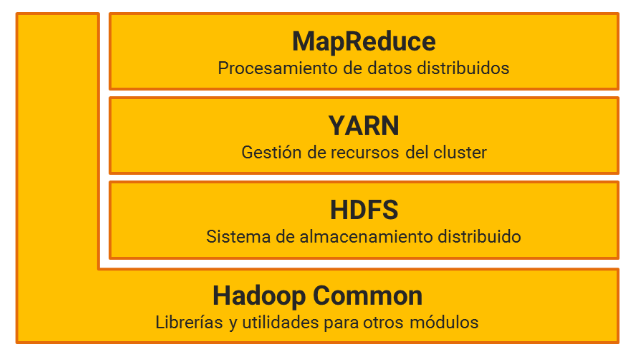

A continuacion veremos en profundidad alguno de estos modulos:

### HDFS o Sistema distribuido de ficheros de Hadoop

**Es un sistema escalable y tolerante a fallos, para almacenar grandes volumenes de informacion de manera distribuida en un cluster de maquinas**

> Esta escrito en *Java*

Su funcionamiento caracteristico permite trabajar con **teraybytes**. Para ello **trocea, reparte y replica la info en los nodos**, para poder desarrollar su procesamiento y mantener los 3 principios de un sistema big data (*latencia adecuada, almacenamiento big data y tolerancia a fallos*)

Un cluster de este tipo de sistema, esta compuesto por 2 tipos de nodos: ***NameNode*** y ***DataNodes***.

> La idea es que cada nodo este en una maquina distinta
>
> Ademas si estos nodos estan en otras subredes, *racks*, lo puede tener en cuenta para ver la proximidad de una maquina u otra a la hora de gestionar.

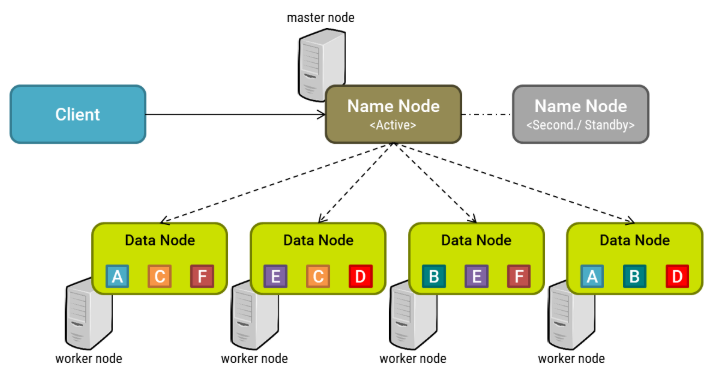

#### *NameNode*

**Es el punto de acceso al sistema de ficheros y se encarga de almacenar los metadatos**. Incluye dentro de si:

- el nombre de los ficheros y jerarquias de los directorios almacenados
- los permisos de acesso
- la ubicacion de cada uno de los bloques en el cluster.

> **Es el elemento mas importante del sistema**

Para agilizar el proceso, **estos se almacenan en memoria**

Otras funciones tiene que ver con **la gestion de los *DataNodes*** en la que se incluyen:

- Coordinar la operativa de los *DataNodes*
- Monitorizar el estado de los *DataNodes* y el nº de replicas activas
- Generando replicas de cada bloque en el cluster, para evitar perdidas en los fallos de las maquinas
- Enviandoles instrucciones para atender las operaciones.

Como se puede ver, este punto **si es susceptible de fallo, generaria un fallo global en la estructura**

Para evitarlo existen 2 alternativas:

- 1º A traves de un *NameNode Secundario*: Se encarga de copiar a intervalos regulares los metadatos del *NameNode* primario para almacenarlos en local o remotos. Por tanto en caso de fallo **es posible reiniciar el servicio recuperando lso metadatos de las copias**
> Es la configuracion por defecto ya que consume menos recursos y es mas sencilla de configurar que la 2º opcion.
- 2º A traves de un *NameNode en Standby*: Es un *NameNode* se actualiza de manera continua, de modo que si cae, automaticamente el sistema sigue operando con él (*fail-over*) y **sustituye al *NameNode* principal**
> Esta segunda opcion se utiliza para sistemas de alta disponibilidad.
>
> Dado que solo se puede configurar 1 de los 2, hay que tener muy en cuenta cual configurar.

#### *DataNode*

**Son los nodos responsables de almacenar y servir informacion al sistema**

> El HDFS esta compuesto por multitud de estos, hasta miles.

Esos nodos albergan el tamaño minimo de los metadatos que se necesitan, **en bloques de codigo de entre 64 y 128 Mb**. Estos bloques se reparten entre los nodos tratando de quilibrar el volumen de datos.

> Esta regla implica que el peso de los archivos tiene establecido un peso minimo de 64 MB, por lo que **si trabajas con archivos inferiores de peso, este los *inflara hasta 64Mb***( Ej: 1 archivo de 1 Mb, sera gestionado como si pesara 64Mb)
>

Estos nodos implementan estas funcionalidades para su operativa:

- Se realizan **las replicas de bloques para la tolerancia al fallo**.
  
> Por defecto se replican *3X* cada bloque, siendo una regla de que 2 de estas 3 copias se guardan en el mismo rack y la 3º en otro rack, asi siempre hay una copia de cada bloque.

- Si falla un nodo, **procede a ordenar la replicacion de los bloques que tenia asignados al resto de nodos**
  
> Los nodos se comunican y asi se pueden reequilibrar el volumen de datos entre ellos, mueven copias y generan replicas nuevas

Por ultimo, el sistema en si tiene una limitacion importante: 

***Si los datos de origen se tienen que modificar, este sistema de archivos es ineficiente para ello, ya que todo el proceso esta pensado para trabajar datos finales***

> Implicaria tener que hacer todo el proceso de troceado, particionado, replicas, distribucion,...


### *YARN*

**Es un gestor de recursos distribuidos, *un sistema operativo* para administrar los recursos del cluster, ayudando a la coordinacion y planificacion de su uso en base a los trabajos que tiene que realizar**

> Los recursos a gestionar son unidades de CPU virtuales, con capacidad de memoria RAM para realizar calculos y procesar datos.
>
> **Como concepcion, hay nodos que prestan sus capacidades (*esclavos*) y otros que controlan y administran los recursos (*maestros*).**

Este gestor esta compuesto por varios componentes para realizar la administracion de recursos:

- ***ResourceManager***: un gestor de recursos global del sistema, que se ejecuta en el nodo maestro.
- ***NodeManager***: en cada nodo esclavo, gestiona localmente el nodo.
- ***Containers***: en cada nodo esclavo, representa los recursos de CPU y RAM disponibles para la ejecucion del trabajo a realizar.
- ***ApplicationMaster***: para cada trabajo a realizar que se lance en la plataforma.

En esta imagen se ve la interrelacion de los elementos:

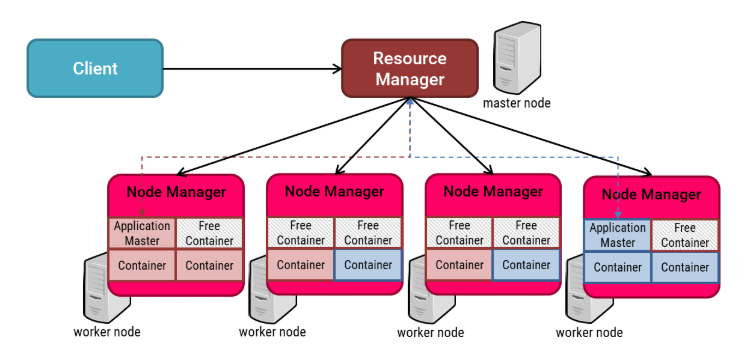

#### ¿Como funciona YARN?

Aqui se explica en resumen como todos los componentes/sistemas se interrelacionan para que funcione el gestor de recursos:

- 1º Un usuario genera una solicitud al *ResourceManager* para ejecutar un trabajo/aplicacion
> Esta solicitud incluye **el codigo de la aplicacion y la informacion extra para llevarla a cabo**
>
> > Es el llamado *contexto de ejecucion*: parametros, datos de configuracion y otra info (librerias, ficheros,...)
- 2º El *ApplicationMaster* del *ResourceManager* asigna un 1º container para iniciar el iniciador del *ApplicationMaster* que gestiona la aplicacion a ejecutar.
- 3º Una vez ejecutada iniciada la aplicacion, se comunica al *ResourceManager*  el resto de containers necesarios para poder ejecutar el resto de tareas de la aplicacion.
- 4º El *ResourceManager* gestiona la reserva de containers en los nodos y le indica al *ApplicationMaster* la asignacion.
- 5º El *ApplicationMaster* contacta con cada *NodeManager* de sus nodos asignados y solicita que active los containers
> Aqui les copia la informacion del contexto de ejecucion.
- 6º Una vez habilitado el acceso a los containers, el *ApplicationMaster*  procede a ejecutar la aplicacion.
> Aqui el *ApplicationMaster* planifica las tareas a ejecutar en cada container, controla los recursos y monitoriza la evolucion de las tareas
>
> Ademas comunica al *ResourceManager* el estado de ejecucion y recursos.
- 7º Una vez completada la aplicacion/trabajo, el *ApplicationMaster* comunica al *ResourceManager* de la finalizacion, se procede a eliminar los registros para la ejecucion de la aplicacion, libera los containers asignados y deja los recursos disponibles para otras aplicaciones.

#### *ResourceManager*

**Es el proceso principal del sistema, quien lleva el control de los recursos del cluster y orquesta el correcto uso y funcionamiento de los elementos del sistema**

> Se convierte en el **punto de acceso para el usuario**: Si desea lanzar un trabajo, ha de iniciarlo y para que lo lance.

Su funcion principal es **arbitrar el reparto de los recursos disponibles entre los trabajos solicitados y que demandan recursos**. Su objetivo es optimizar al maximo estos recursos.

Para ello se utilizan otros procesos auxiliares, que son:

- ***Scheduler***: planifica las solicitudes de recursos en base a los trabajos y asigna el trabajo, en funcion de su disponibilidad y carga.
> Se puede configurar para que *meta en cola* solicitudes si no hay recursos
- ***ApplicacionsManager***: gestiona y mantiene actualizada la informacion de los dtrabajos, controla el estado de ejecucion y finalizacion.

Por ultimo, se puede configurar el proceso para que en caso de fallo (*fail-over*) **se lance otro proceso *ResourceManager* sustitutivo**

#### *NodeManager*

**Es el proceso encargado de gestionar los recursos locales de un nodo *esclavo*.** 

> Existe 1 por nodo esclavo

Este sistema, **esta en constante comunicacion con el *ResourceManager*** funciona asi:

- El *NodeManager* establece mensajes regulares llamados *latidos* que indican el estado del nodo y sus recursos
- Si la latencia aumenta o existe ausencia de los mensajes, el *ResourceManager* iniciara los protocolos para recuperar el nodo o redistribuir el trabajo en el resto del cluster
  
> Asi se evitan fallos y perdidas de informacion

Ademas el sistema **establece el uso de *containers*** con varias funciones:

- Configura y activa un nuevo container con los recursos necsarios para realizar el trabajo.
- Monitoriza el uso hasta que se ha completado el trabajo
- Destruye el container una vez realizado el trabajo.

#### *Containers*

**Es la representacion de un conjunto de recursos de un nodo particular y reservados para un trabajo**

> Estos recursos son CPU y bloques de memoria RAM, aunque puede incluir, uso de disco, ancho de banda...

Estos se crean cuando un al solicitar un trabajo, un *ApplicationMaster* determina con el *ResourceManager* los recursos necesarios para ejecutarse. Al hacerlo, **se genera un listado definido de *containers* sobre la configuracion de los recursos minimos de los mismos**

Estos elementos garantizan:

- Un acceso minimo a recursos para completar los trabajos
- Procura un reparto adecuado de los recursos para el trabajo de manera optimizada
- Asegura que los procesos para llevar a cabo el trabajo, no se comprometen y la informacion es resguardada

#### *ApplicationManager*

**Es el responsable de la ejecucion de los trabajos o lo que es lo mismo, el responsable de gestionar todo el ciclo de vida de las tareas en los containers asignados**

- Controla el flujo de ejecucion
- Controla fallos que puedna ocurrir en el trabajo.
- Monitoriza el consumo de los recursos en las tareas.

> Cada trabajo tiene 1

Este sistema **viene proporcionado por la libreria utilizada para definir el trabajo, como SPARK**

> Por tanto YARN aqui lo unico que hace es definir como se comportara y comunicara con el resto de elementos.

Su funcionalidad principal consiste en solicitar los recursos al *ResourceManager* para completar su trabajo, dando estas ordenes:

- Indicando el numero de containers necesarios
- Definiendo las caracteristicas de los containers
- Estableciendo las preferencias de nodos para habilitar los containers

> Este ultimo punto es la llamada *colocacion* y permite que **se seleccionen los nodos donde se van a ejecutar los datos en los mismos donde se almacenan los datos**

Finalizado este proceso, el *ResourceManager* da una respuesta con los recursos solicitados, y el *ApplicationManager* contacta con cada uno de los Nodemanager donde se le ha asignado el container para poder lanzar sus tareas.

Por tanto este sistema dispone de un sistema de comunicacion con el *ResourceManager* parecido al *NodeManager*, ya que genera latidos con datos tipo:

- Estado del trabajo
- Uso de recursos asignados
- Posible peticiones para ampliar recursos

> Asi se libera trabajo al *ResourceManager* y añade una capa de seguridad en los procesos de los oros sistemas, para que no se bloquee con las peticiones de varios *ApplicationMaster*


### ¿Como se integran *HDFS y YARN*?

La idea de Hadoop en la configuracion del sistema es intentar conseguir la *colocalizacion*: **la maquina donde estan los datos albergados es la misma donde se ejecutan las tareas**

Para conseguir esto Hadoop hace uso de los elementos que tiene a su alcance donde **se configuran los *nodos maestro de HDFS* y YARN (*ResourceManager*) en una misma maquina y los *nodos esclavo* en cada maquina, creando *DataNodes de HDFS* y YARN (*NodeManager*) en cada uno de los nodos del cluster**

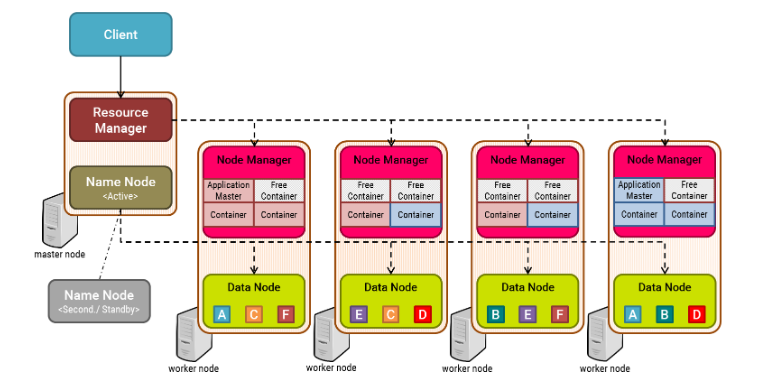

> Ademas, cuando una aplicaicon *MapReduce* va ejecutarse, su *ApplicationMaster* puede consultar en que nodos estan los datos y solicita que sus recursos o containers esten en las mismas maquinas

#### ¿Por que este tipo de arquitectura esta en desuso?

La exponencialidad de datos hace que esta norma de *colocalizacion* sea un problema.

En 1º lugar, la arquitectura **no asegura que se vaya a procesar los datos en el mismo lugar que se almacenan** ya que puede ser que no haya **suficientes recursos disponibles en el nodo** lo que implica que se ejecutara en otro nodo distinto.

En 2º lugar, porque es el mismo problema de escalabilidad que un *datawarehouse* aunque este mas automatizado: **No se puede crecer tan rapido frente a la entrada de generacion de datos**

Entonces la solucion que se esta tendiendo consiste en *separar el procesamiento y el almacenado y conectarlo*: **desplegar maquinas con caractertisticas (unas mas destinadas a la replica y guardado de la informacion, otras a la ejecucion) distintas conectados por redes de alta velocidad**

### *MapReduce*

**Es un modelo de programacion para procesar grandes cantidades de informacion, diviendo el trabajo en tareas que se ejecutan en paralelo en varios nodos del cluster**

> Su naturaleza es procesar un conjunto de datos siguiendo una sencuencia de pasos

En Python vimos las *funciones de orden superior* que reciben u entregan una funcion como resultado. La funcion *Map* sirve para aplicar una funcion a cada uno de los valores de una serie de datos. La funcion *Reduce* aplica una funcion sobre una serie de valores, acumulando los valores intermedios hasta obtener un unico resultado final.

Nos sirve para entender este modelo:

- 1º Se aplica una funcion a los datos de entrada para obtener los valores intermedios
- 2º Se aplica una segunda funcion que combine y reduzca estios valores a un resultado final.

In [1]:
from functools import reduce
lista = [4,6.3,6,-6,231,4]
f_map = map(lambda x: (x*(x-1)), lista)
f_reduce = reduce(lambda x, y: x-y, f_map)
print(f_reduce)

-53235.39


Aunque elementalmente funciona asi, por su capacidad de funciona idependientemente y realizar en paralelo, pero cuando hablamos de big data **no estan sencillo**

Por eso esta herramienta se ha convertido en **un tipo de aplicacion mas**, disponible en una libreria de Hadoop, con sus *ApplicationMaster* y otrso componentes adaptados.

> Originalmente las funciones del YARN y el motor estaban unidos, pero al separarlo, se flexibilizo el uso de Haddop y quito complejidad.

Como hemos definido antes, *es un proceso que consta de pasos*, estos pasos estaran **sera una combinacion de tareas que nos interese realizar y otros predefinidos.**

En el siguiente ejemplo vemos un ejemplo de las etapas de MapReduce ejecutando un programa que **cuenta el nº de palabras que aparece en un fichero de texto**

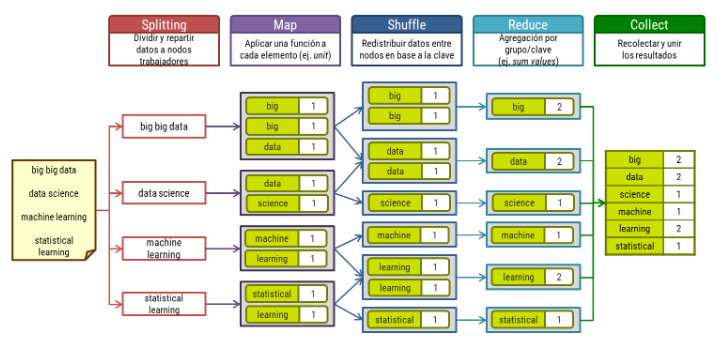

#### 1º Paso *MapReduce*: Carga y Reparticion inicial

Se inicia leyendo los datos del fichero, dividiendolos y repartiendolos en los procesos de la siguiente etapa

El formato de los archivos HDFS **puede ser cualquiera** (desde formato txt, en binario,...) de modo que al sistema hay que indicarle **cual es el formato de entrada**

> Si se desea utilizar un formato no nativo en el sistema, es posible mediante una implementacion sobre funciones que leen y reparten.

Por tanto, una vez se sabe el formato de lectura, **se leen y se dividen en bloques de procesamiento para la siguiente fase, *Map***

#### 2º Paso *MapReduce*: *Map*

En esta etapa se toman los datos recibidos y **se procesan aplicando una funcion definida por el usuario, que genera valores intermedios en la salida**

Esta etapa es definida por el usuario y las funciones ejecutadas se llaman ***mappers***.

> **Estos Mappers solo deben respetar la forma en la que recibe y devuelve los datos para interconectarse con el resto de elementos**

En esta etapa, la funcion *map* funciona asi:

- 1º Recibe un identificador y dato de la etapa anterior
> Como un diccionario en Python, clave y valor
- 2º Genera un numero determinado de *pares* formado por una clave y valor
> El contenido de la clave y el valor, **dependera de la funcion implementada por el usuario**

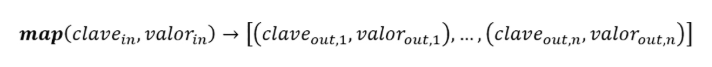

En principio hasta aqui termina esta fase, pero se puede utilizar otra estructura llamada *Combiners* aprovechando los ***mappers*** aplicados que permiten **realizar algunos calculos posteriores en los mismos nodos**. Estas estructuras para utilizarse deben cumplir una regla:

*Se debe garantizar que el resultado final es el mismo incluyendo el combinaer o dejandolo fuera de la cadena de procesos*
> La funcion del combiner ha de **dar el mismo resultado final, independientemente del numero de veces que le apliquemos la funcion**

#### 3º Paso *MapReduce*: Reordenacion y reparto

En esta etapa los resultados intermedios, compuestos por clave y valor, **son divididos en base a su clave para enviarse a los mismos nodos**

> ***Por tanto hay 2 tareas: 1º se dividen, 2º se envian***

Esta etapa se introduce otro elemento para la 1º tarea, los *Partitioners* **encargados de realizar esta division de resultados.**

Estos elementos tienen 2 funciones:

- 1º Repartir los resultados con distintas claves en distintos nodos
- 2º Asegurarse que los resultados con mismas claves van a mismos nodos

De la 2º tarea, el envio de los repartos, se denomina *shuffling*. En esta etapa termina tras un proceso de **ordenacion de datos en base a la clave**

> Esta ordenacion permite conocer **cuantas funciones *Reduce* sera necesaria hacer en cada nodo** teniendo en cuenta:
>
>> 1º Un nodo puede tener varias claves con resultados a procesar
>>
>> 2º Se realiza una funcion *Reduce* por clave.

#### 4º Paso *MapReduce*: Reduce

En esta etapa se toman los resultados intermedios divididos por claves y **son procesados con una funcion definida por el usuario para generar resultados finales**.

Esta etapa es definida por el usuario y las funciones ejecutadas se llaman ***reducers***.

> **Al igual que con los *mappers* es necesario respetar la forma en la que entran y salen los datos**
>

Estos elementos **reciben una clave de entrada y una lista de valores asociados y como resultado se obtiene uno mas pares finales**

> *No deben generarse pares con claves repetidas*
>

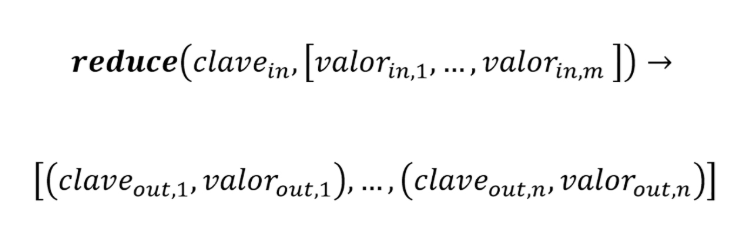

Algunas funcionalidades que aplican sobre el conjunto de datos, son:

- Generar agregaciones.
- Generar filtrados.
- Generar transformaciones de los valores.


#### 5º Paso *MapReduce*: Recopilacion

Esta etapa final consiste en **recolectar los resultados generados por los procesos *reducer* y combinarlos para producir la salida final** en un conjunto de ficheros HDFS